### 4 · LangGraph RAG Flow

A basic LangGraph agent that routes queries to the right retriever,
fetches relevant docs, and generates an answer.

### Graph
```
START → route_query → retrieve_docs → generate_answer → END
```

- **route_query** — LLM classifies the query and picks a retriever
- **retrieve_docs** — Runs similarity search on the selected vectorstore
- **generate_answer** — LLM answers the question using retrieved context

In [1]:
from pathlib import Path
from typing import Annotated, TypedDict, Literal

from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import END, StateGraph
from dotenv import load_dotenv

load_dotenv(override=True)

# ── Config ────────────────────────────────────────────────────────────────────
VECTORSTORE_DIR = Path("../data/vectorstore")
EMBEDDING_MODEL = "text-embedding-3-small"
LLM_MODEL = "gpt-4o-mini"

print("Imports loaded.")

Imports loaded.


---
### Step 1 — Load Retrievers

Each retriever is a named tool the router can pick from.
For now we only have one (`admin_tech_docs`), but the structure
supports adding more later (e.g., `business_metrics`, `hr_policies`).

In [2]:
embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL)

# ── Retriever registry ────────────────────────────────────────────────────────
# Add new retrievers here as you build more vectorstores

admin_tech_store = FAISS.load_local(
    str(VECTORSTORE_DIR), embeddings, allow_dangerous_deserialization=True
)

RETRIEVERS = {
    "admin_tech_docs": {
        "retriever": admin_tech_store.as_retriever(search_kwargs={"k": 5}),
        "description": "Technical documentation for the AMS Admin Tool — architecture, features, code quality, operations.",
    },
    # "business_metrics": {
    #     "retriever": business_store.as_retriever(search_kwargs={"k": 5}),
    #     "description": "Business KPIs, revenue data, quarterly reports.",
    # },
}

print(f"Registered retrievers: {list(RETRIEVERS.keys())}")

Registered retrievers: ['admin_tech_docs']


---
### Step 2 — Define Graph State

The state flows through every node. Each node reads from it and writes back.

In [3]:
class GraphState(TypedDict):
    """State that flows through the RAG graph."""
    question: str                    # user's original question
    retriever_name: str              # which retriever to use (set by router)
    documents: list[Document]        # retrieved chunks
    answer: str                      # final generated answer

print("State schema defined.")

State schema defined.


---
### Step 3 — Define Nodes

Three nodes:
1. **route_query** — LLM classifies the query → picks a retriever name
2. **retrieve_docs** — Runs the selected retriever
3. **generate_answer** — LLM answers using the retrieved context

In [4]:
llm = ChatOpenAI(model=LLM_MODEL, temperature=0)

# ── Node 1: Route Query ──────────────────────────────────────────────────────

ROUTER_PROMPT = ChatPromptTemplate.from_messages([
    ("system",
     "You are a query router. Given a user question, decide which knowledge base "
     "to search. You MUST respond with ONLY the retriever name, nothing else.\n\n"
     "Available retrievers:\n"
     "{retriever_list}\n\n"
     "If the question doesn't clearly match any retriever, default to: admin_tech_docs"),
    ("human", "{question}"),
])

def route_query(state: GraphState) -> dict:
    """LLM decides which retriever to use based on the question."""
    retriever_list = "\n".join(
        f"- {name}: {info['description']}"
        for name, info in RETRIEVERS.items()
    )
    chain = ROUTER_PROMPT | llm | StrOutputParser()
    chosen = chain.invoke({
        "question": state["question"],
        "retriever_list": retriever_list,
    }).strip()

    # Fallback if LLM returns something unexpected
    if chosen not in RETRIEVERS:
        chosen = "admin_tech_docs"

    print(f"  [router] → {chosen}")
    return {"retriever_name": chosen}


# ── Node 2: Retrieve Docs ────────────────────────────────────────────────────

def retrieve_docs(state: GraphState) -> dict:
    """Fetch relevant documents from the selected retriever."""
    retriever = RETRIEVERS[state["retriever_name"]]["retriever"]
    docs = retriever.invoke(state["question"])
    print(f"  [retrieve] → {len(docs)} chunks from '{state['retriever_name']}'")
    return {"documents": docs}


# ── Node 3: Generate Answer ──────────────────────────────────────────────────

ANSWER_PROMPT = ChatPromptTemplate.from_messages([
    ("system",
     "You are a helpful assistant for the AMS Admin Tool team. "
     "Use the following context to answer the user's question accurately and concisely. "
     "If the context doesn't contain enough information, say so — don't make things up.\n\n"
     "Context:\n{context}"),
    ("human", "{question}"),
])

def generate_answer(state: GraphState) -> dict:
    """Generate a final answer using retrieved context."""
    context = "\n\n---\n\n".join(
        f"[{doc.metadata.get('source', '?')} > {doc.metadata.get('section', '?')}]\n{doc.page_content}"
        for doc in state["documents"]
    )
    chain = ANSWER_PROMPT | llm | StrOutputParser()
    answer = chain.invoke({
        "question": state["question"],
        "context": context,
    })
    print(f"  [generate] → answer ready ({len(answer)} chars)")
    return {"answer": answer}


print("Nodes defined: route_query, retrieve_docs, generate_answer")

Nodes defined: route_query, retrieve_docs, generate_answer


---
### Step 4 — Build the Graph

Wire the nodes into a linear LangGraph flow:
```
START → route_query → retrieve_docs → generate_answer → END
```

In [5]:
workflow = StateGraph(GraphState)

# Add nodes
workflow.add_node("route_query", route_query)
workflow.add_node("retrieve_docs", retrieve_docs)
workflow.add_node("generate_answer", generate_answer)

# Wire edges
workflow.set_entry_point("route_query")
workflow.add_edge("route_query", "retrieve_docs")
workflow.add_edge("retrieve_docs", "generate_answer")
workflow.add_edge("generate_answer", END)

# Compile
graph = workflow.compile()

print("Graph compiled.")

Graph compiled.


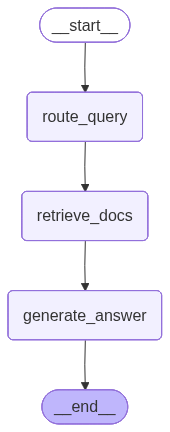

In [6]:
# Visualize the graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

---
### Step 5 — Test the Graph

In [7]:
# ── Test 1: Architecture question ────────────────────────────────────────────

question = "How is state management handled in the application?"
print(f"Question: {question}\n")

result = graph.invoke({"question": question})

print(f"\nRetriever used: {result['retriever_name']}")
print(f"Docs retrieved: {len(result['documents'])}")
print(f"\n{'='*70}")
print("ANSWER:")
print("="*70)
print(result["answer"])

Question: How is state management handled in the application?

  [router] → admin_tech_docs
  [retrieve] → 5 chunks from 'admin_tech_docs'
  [generate] → answer ready (1286 chars)

Retriever used: admin_tech_docs
Docs retrieved: 5

ANSWER:
State management in the AMS Admin Tool is handled using a combination of technologies tailored for different types of state:

1. **Redux Toolkit**: Used for global client-side state management, particularly for complex UI states that need to be shared across unrelated component trees. This includes the journey editor, journey builder, authentication, and theme preferences.

2. **TanStack Query**: Manages server data such as journeys, action types, and history entries. It handles caching, refetching, and server synchronization, allowing Redux to focus on UI orchestration.

3. **redux-persist**: Used for persisted local state, such as builder drafts and theme preferences, ensuring that user settings are retained across sessions.

4. **useState / useRed

In [13]:
# ── Test 2: Feature question ─────────────────────────────────────────────────

import pprint


question = "What is the journey canvas and how does it work?"
print(f"Question: {question}\n")

result = graph.invoke({"question": question})

print(f"\nRetriever used: {result['retriever_name']}")
print(f"Docs retrieved: {len(result['documents'])}")
print(f"\n{'='*70}")
print("ANSWER:")
print("="*70)
print(result["answer"])

Question: What is the journey canvas and how does it work?

  [router] → admin_tech_docs
  [retrieve] → 5 chunks from 'admin_tech_docs'
  [generate] → answer ready (1355 chars)

Retriever used: admin_tech_docs
Docs retrieved: 5

ANSWER:
The Journey Canvas is a visual graph editor within the AMS Admin Tool that allows users to build, edit, and understand the flow of call center agent screens. It renders CMS2 journey configurations as an interactive node-and-edge flowchart. 

The canvas supports two main functionalities: the **Journey Editor**, which is used for editing existing journeys from Firestore, and the **Journey Builder**, which is for creating new journeys from scratch. 

It is built on **React Flow** (`@xyflow/react`), providing features such as drag-and-drop node creation, visual edge connections, auto-layout via **dagre**, and real-time synchronization with the Redux store.

The canvas operates in two distinct contexts:

1. **Journey Editor**: 
   - Page: `/editor/:journeyId

In [9]:
# ── Test 3: Code quality question ────────────────────────────────────────────

question = "What are the anti-patterns I should avoid in the codebase?"
print(f"Question: {question}\n")

result = graph.invoke({"question": question})

print(f"\nRetriever used: {result['retriever_name']}")
print(f"Docs retrieved: {len(result['documents'])}")
print(f"\n{'='*70}")
print("ANSWER:")
print("="*70)
print(result["answer"])

Question: What are the anti-patterns I should avoid in the codebase?

  [router] → admin_tech_docs
  [retrieve] → 5 chunks from 'admin_tech_docs'
  [generate] → answer ready (970 chars)

Retriever used: admin_tech_docs
Docs retrieved: 5

ANSWER:
You should avoid the following anti-patterns in the codebase:

1. **Storing server data in Redux** - Use TanStack Query for server data instead.
2. **Dispatching in render** - This can cause infinite re-render loops; use `useEffect` or callbacks instead.
3. **Reading stale closure state in async operations** - Use `store.getState()` for fresh reads.
4. **Mutating state outside Immer (Redux reducers)** - Always mutate state inside reducer functions.
5. **No Firestore security rules** - Implement rules for defense-in-depth.
6. **Variables use shared collection** - Ensure `script-variables` is environment-scoped.
7. **No pagination on full collection reads** - Avoid fetching every document at once; implement pagination.
8. **Compatibility wrapper 

In [10]:
# ── Test 4: Out-of-domain question ───────────────────────────────────────────

question = "What is the weather in Mumbai today?"
print(f"Question: {question}\n")

result = graph.invoke({"question": question})

print(f"\nRetriever used: {result['retriever_name']}")
print(f"Docs retrieved: {len(result['documents'])}")
print(f"\n{'='*70}")
print("ANSWER:")
print("="*70)
print(result["answer"])

Question: What is the weather in Mumbai today?

  [router] → admin_tech_docs
  [retrieve] → 5 chunks from 'admin_tech_docs'
  [generate] → answer ready (183 chars)

Retriever used: admin_tech_docs
Docs retrieved: 5

ANSWER:
I'm sorry, but I don't have access to real-time data, including current weather information. You may want to check a weather website or app for the latest updates on Mumbai's weather.


---
### Step 6 — Inspect Retrieved Context

Peek inside the state to see exactly what the retriever found.

In [11]:
# Show the retrieved docs from the last query

print(f"Question: {result['question']}")
print(f"Retriever: {result['retriever_name']}\n")

for i, doc in enumerate(result["documents"]):
    m = doc.metadata
    print(f"Chunk [{i}]")
    print(f"  source:  {m.get('source', '?')}")
    print(f"  section: {m.get('section', '?')}")
    print(f"  type:    {m.get('doc_type', '?')}")
    print(f"  content: {doc.page_content[:150]}...")
    print()

Question: What is the weather in Mumbai today?
Retriever: admin_tech_docs

Chunk [0]
  source:  architecture/code-quality.md
  section: Code Quality & Style Guide for Developers
  type:    architecture
  content: # Code Quality & Style Guide for Developers  
> **Parent:** [Architecture](./architecture.md)
> **Last Updated:** March 2026  
---...

Chunk [1]
  source:  operations/code-quality-audit-plan.md
  section: Current State (as of today)
  type:    operations
  content: ## Current State (as of today)  
| Metric                                    | Value                                                                  ...

Chunk [2]
  source:  architecture/overview.md
  section: Firestore Compatibility Layer
  type:    architecture
  content: ### Firestore Compatibility Layer  
The `firebase/index.ts` provides a wrapper around the Firebase v9 modular SDK that mimics the v8 chained API patte...

Chunk [3]
  source:  features/action-builder.md
  section: Firestore Collections
  type: 

---
### Summary

| Node | What it does | Extensible? |
|------|-------------|-------------|
| `route_query` | LLM picks the right retriever | Add new entries to `RETRIEVERS` dict |
| `retrieve_docs` | Fetches top-k chunks from FAISS | Swap in any LangChain retriever |
| `generate_answer` | LLM answers with context | Change prompt, add citations |

**Next steps:**
- Add more retrievers (business docs, CSV data, etc.)
- Add conditional edges (e.g., skip retrieval for general chat)
- Add memory / chat history for multi-turn conversations
- Wire into `app/graphs/agent.py` for production use